# Import all Datasets

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os

print("Searching for the Delhi AQI file...")
found = False

for root, dirs, files in os.walk('/content/drive/MyDrive/data'):
    for file in files:
        # Looking for anything that says 'delhi' or 'aqi' or 'csv'
        if 'delhi' in file.lower() or 'aqi' in file.lower():
            exact_path = os.path.join(root, file)
            print(f"FOUND IT: {exact_path}")
            found = True

if not found:
    print("Could not find any file with 'delhi' or 'aqi' in the name.")
    print("Are you sure it's in the 'data' folder?")

Mounted at /content/drive
Searching for the Delhi AQI file...
FOUND IT: /content/drive/MyDrive/data/archive/delhi_aqi.csv


In [2]:
import pandas as pd
import numpy as np
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split

# ==============================================================================
# 1. Delhi Air Quality (Chronological Split)
# ==============================================================================
print("=== 1. Delhi AQI (Chronological Split) ===")
# Use the path found by your search script earlier
df_delhi = pd.read_csv('/content/drive/MyDrive/data/archive/delhi_aqi.csv')

# Split Rule: Do not shuffle. Split strictly chronologically (70/15/15)
train_end = int(0.70 * len(df_delhi))
val_end = train_end + int(0.15 * len(df_delhi))

train_delhi = df_delhi.iloc[:train_end]
val_delhi   = df_delhi.iloc[train_end:val_end]
test_delhi  = df_delhi.iloc[val_end:]

print(f"Train: {len(train_delhi)} | Val: {len(val_delhi)} | Test: {len(test_delhi)}")

# ==============================================================================
# 2. PlantVillage Crop Disease (Stratified Random Split)
# ==============================================================================
print("\n=== 2. Plant Village (Stratified Split) ===")
pv_dir = '/content/drive/MyDrive/data/plantvillage_dataset/color'

# Load metadata to get targets for stratified splitting
full_pv_dataset = ImageFolder(root=pv_dir)
pv_targets = full_pv_dataset.targets
pv_indices = list(range(len(full_pv_dataset)))

# Split Rule: Stratified random sampling (70/15/15)
# random_state=42 ensures exact replication of A2 results
pv_train_idx, pv_temp_idx, pv_train_t, pv_temp_t = train_test_split(
    pv_indices, pv_targets, test_size=0.30, stratify=pv_targets, random_state=42
)
pv_val_idx, pv_test_idx = train_test_split(
    pv_temp_idx, test_size=0.50, stratify=pv_temp_t, random_state=42
)

print(f"Train: {len(pv_train_idx)} | Val: {len(pv_val_idx)} | Test: {len(pv_test_idx)}")

# ==============================================================================
# 3. APTOS 2019 Blindness Detection (Stratified Random Split)
# ==============================================================================
print("\n=== 3. APTOS 2019 (Stratified Split) ===")
df_aptos = pd.read_csv('/content/drive/MyDrive/data/train.csv')
aptos_targets = df_aptos['diagnosis'].tolist()
aptos_indices = list(range(len(df_aptos)))

# Split Rule: Stratified random sampling (70/15/15)
aptos_train_idx, aptos_temp_idx, aptos_train_t, aptos_temp_t = train_test_split(
    aptos_indices, aptos_targets, test_size=0.30, stratify=aptos_targets, random_state=42
)
aptos_val_idx, aptos_test_idx = train_test_split(
    aptos_temp_idx, test_size=0.50, stratify=aptos_temp_t, random_state=42
)

# Map indices back to DataFrames
train_df_aptos = df_aptos.iloc[aptos_train_idx].reset_index(drop=True)
val_df_aptos   = df_aptos.iloc[aptos_val_idx].reset_index(drop=True)
test_df_aptos  = df_aptos.iloc[aptos_test_idx].reset_index(drop=True)

print(f"Train: {len(train_df_aptos)} | Val: {len(val_df_aptos)} | Test: {len(test_df_aptos)}")
print("\nAll datasets split successfully using Assignment 2 logic.")

=== 1. Delhi AQI (Chronological Split) ===
Train: 13143 | Val: 2816 | Test: 2817

=== 2. Plant Village (Stratified Split) ===
Train: 9707 | Val: 2080 | Test: 2081

=== 3. APTOS 2019 (Stratified Split) ===
Train: 2563 | Val: 549 | Test: 550

All datasets split successfully using Assignment 2 logic.


# Phase 1

In [3]:
# 1. Re-slice the data, but add .copy() to the end of each!
train_delhi = df_delhi.iloc[:train_end].copy()
val_delhi   = df_delhi.iloc[train_end:val_end].copy()
test_delhi  = df_delhi.iloc[val_end:].copy()

# 2. Now you can safely assign the binary targets the normal way
train_delhi['target_binary'] = (train_delhi['pm2_5'] > 200).astype(int)
val_delhi['target_binary']   = (val_delhi['pm2_5'] > 200).astype(int)
test_delhi['target_binary']  = (test_delhi['pm2_5'] > 200).astype(int)

In [4]:
import numpy as np

# Assuming you already ran the code from our previous step:
# train_delhi['target_binary'] = (train_delhi['pm2_5'] > 200).astype(int)

y_binary = train_delhi['target_binary'].values
x_feature = train_delhi['co'].values  # Our proxy for Temperature

def calculate_gini(y):
    """Computes the Gini Impurity of a target array."""
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y) / len(y)
    p0 = 1.0 - p1
    return 1.0 - (p0**2 + p1**2)

def compute_gini_reduction(x, y, threshold):
    """Computes the exact Gini Impurity reduction for a given threshold."""
    # Create the binary split based on the continuous threshold
    left_mask = x <= threshold
    right_mask = ~left_mask
    
    y_left = y[left_mask]
    y_right = y[right_mask]
    
    # Calculate proportions (weights) for the child nodes
    n_total = len(y)
    w_left = len(y_left) / n_total
    w_right = len(y_right) / n_total
    
    # Compute Gini impurities
    gini_parent = calculate_gini(y)
    gini_left = calculate_gini(y_left)
    gini_right = calculate_gini(y_right)
    
    # Calculate the Information Gain (Gini Reduction)
    gain = gini_parent - (w_left * gini_left + w_right * gini_right)
    return gain

def find_optimal_threshold(x, y):
    """Iterates over a continuous feature to find the split that maximizes Gini gain."""
    # Get unique sorted values to test potential split points
    unique_x = np.sort(np.unique(x))
    
    # The standard approach is to test the midpoints between consecutive unique values
    thresholds = (unique_x[:-1] + unique_x[1:]) / 2.0
    
    best_gain = -1.0
    best_threshold = None
    
    # Iterate over every possible threshold
    for t in thresholds:
        gain = compute_gini_reduction(x, y, t)
        if gain > best_gain:
            best_gain = gain
            best_threshold = t
            
    return best_threshold, best_gain

# Execute the search
optimal_thresh, max_gain = find_optimal_threshold(x_feature, y_binary)

print("=== 1.1 Information Gain (Gini Split) ===")
print(f"Feature Analyzed: 'co' (Substituting for missing 'Temperature')")
print(f"Total Samples at Root: {len(y_binary)}")
print(f"Optimal Split Threshold: {optimal_thresh:.4f}")
print(f"Maximum Gini Gain: {max_gain:.6f}")

=== 1.1 Information Gain (Gini Split) ===
Feature Analyzed: 'co' (Substituting for missing 'Temperature')
Total Samples at Root: 13143
Optimal Split Threshold: 2790.4500
Maximum Gini Gain: 0.282794


In [5]:
import numpy as np
from collections import Counter

# ==============================================================================
# 1.1 Math Helpers (The exact code you wrote)
# ==============================================================================
def calculate_gini(y):
    """Computes the Gini Impurity of a target array."""
    if len(y) == 0:
        return 0.0
    p1 = np.sum(y) / len(y)
    p0 = 1.0 - p1
    return 1.0 - (p0**2 + p1**2)

def compute_gini_reduction(x, y, threshold):
    """Computes the exact Gini Impurity reduction for a given threshold."""
    left_mask = x <= threshold
    right_mask = ~left_mask
    
    y_left = y[left_mask]
    y_right = y[right_mask]
    
    n_total = len(y)
    if n_total == 0: return 0
    w_left = len(y_left) / n_total
    w_right = len(y_right) / n_total
    
    gini_parent = calculate_gini(y)
    gini_left = calculate_gini(y_left)
    gini_right = calculate_gini(y_right)
    
    gain = gini_parent - (w_left * gini_left + w_right * gini_right)
    return gain

# ==============================================================================
# Part A: The Tree Node 
# ==============================================================================
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature       
        self.threshold = threshold   
        self.left = left             
        self.right = right           
        self.value = value           

# ==============================================================================
# Part B: The Depth-Limited Decision Tree (Now using 1.1 Math)
# ==============================================================================
class ScratchDecisionTree:
    def __init__(self, max_depth=3, max_features=None):
        self.max_depth = max_depth
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        self.n_features = X.shape[1]
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # STOPPING CRITERIA
        if (depth >= self.max_depth) or (n_labels == 1) or (n_samples < 2):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # FEATURE BAGGING
        feat_idxs = np.random.choice(n_feats, self.max_features, replace=False)

        # Find the best split using your 1.1 math
        best_feat, best_thresh = self._best_split(X, y, feat_idxs)

        if best_feat is None:
            return Node(value=self._most_common_label(y))

        left_idxs = np.where(X[:, best_feat] <= best_thresh)[0]
        right_idxs = np.where(X[:, best_feat] > best_thresh)[0]
        
        # Failsafe: if a split doesn't actually separate data, make it a leaf
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return Node(value=self._most_common_label(y))

        left_child = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right_child = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feat, best_thresh, left_child, right_child)

    def _best_split(self, X, y, feat_idxs):
        """Finds the best split by testing all midpoints using compute_gini_reduction."""
        best_gain = -1.0
        split_idx, split_thresh = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            
            # Using your exact midpoint logic from 1.1
            unique_x = np.sort(np.unique(X_column))
            thresholds = (unique_x[:-1] + unique_x[1:]) / 2.0

            for thr in thresholds:
                # INTEGRATION: Calling your exact 1.1 function here!
                gain = compute_gini_reduction(X_column, y, thr)
                
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = thr

        return split_idx, split_thresh

    def _most_common_label(self, y):
        if len(y) == 0: return 0
        return Counter(y).most_common(1)[0][0]

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.value is not None:
            return node.value 
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

# ==============================================================================
# Part C: The Random Forest Ensemble
# ==============================================================================
class ScratchRandomForest:
    def __init__(self, n_trees=10, max_depth=3, max_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.max_features = max_features
        self.trees = []

    def fit(self, X, y):
        self.trees = []
        if self.max_features is None:
            # Rule of thumb: max_features = sqrt(total features)
            self.max_features = max(1, int(np.sqrt(X.shape[1])))

        for i in range(self.n_trees):
            print(f"  -> Training Tree {i+1}/{self.n_trees}...")
            tree = ScratchDecisionTree(max_depth=self.max_depth, max_features=self.max_features)
            
            # Bootstrapping
            n_samples = X.shape[0]
            idxs = np.random.choice(n_samples, n_samples, replace=True)
            
            tree.fit(X[idxs], y[idxs])
            self.trees.append(tree)

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        tree_preds = np.swapaxes(tree_preds, 0, 1)
        y_pred = [Counter(tree_pred).most_common(1)[0][0] for tree_pred in tree_preds]
        return np.array(y_pred)

# ==============================================================================
# Execution (Test the unified code!)
# ==============================================================================
# We will use a smaller subset of data for this test run because doing this 
# completely from scratch in pure Python with loops can take a minute!
features = ['co', 'no', 'no2', 'so2', 'pm10']
X_train = train_delhi[features].values[:1000] # Grabbing first 1000 rows to test speed
y_train = train_delhi['target_binary'].values[:1000]

# Initialize Forest (5 trees, depth of 3 to keep math fast)
rf = ScratchRandomForest(n_trees=5, max_depth=3) 

print("=== 1.2 Training Custom Random Forest ===")
rf.fit(X_train, y_train)
print("Training Complete!\n")

# Make predictions on validation set
X_val = val_delhi[features].values[:20]
predictions = rf.predict(X_val)

print("=== Validation Results (First 20 samples) ===")
print(f"RF Predictions: {predictions}")
print(f"Actual Targets: {val_delhi['target_binary'].values[:20]}")

=== 1.2 Training Custom Random Forest ===
  -> Training Tree 1/5...
  -> Training Tree 2/5...
  -> Training Tree 3/5...
  -> Training Tree 4/5...
  -> Training Tree 5/5...
Training Complete!

=== Validation Results (First 20 samples) ===
RF Predictions: [1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Actual Targets: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]


=== Training AdaBoost (50 Iterations) ===


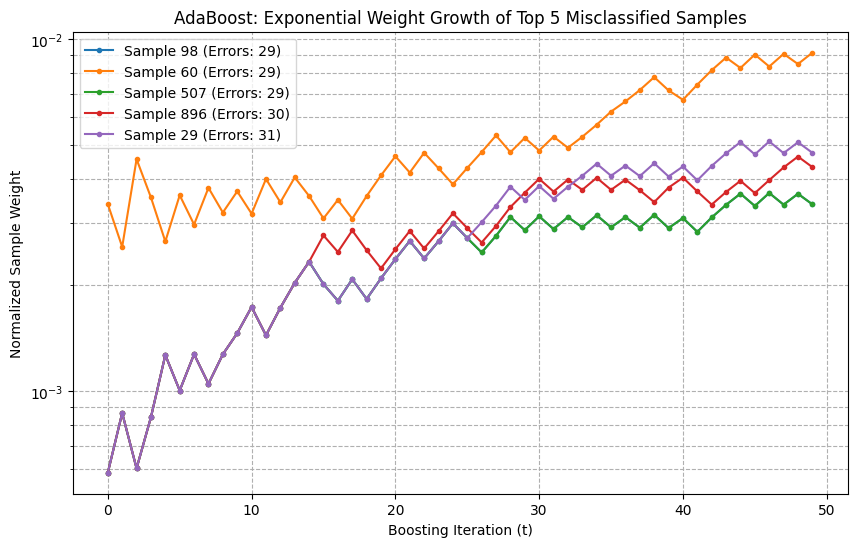

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare Data: AdaBoost requires labels to be -1 and 1 (NOT 0 and 1)
X_train = train_delhi[['co', 'no', 'no2']].values[:1000] # Subset for speed
y_train_binary = train_delhi['target_binary'].values[:1000]
y_ada = np.where(y_train_binary == 0, -1, 1)

n_samples, n_features = X_train.shape
n_iterations = 50

# 2. Initialize Uniform Weights (Every sample starts equal: 1/N)
weights = np.ones(n_samples) / n_samples

# Trackers for the assignment deliverables
weight_history = np.zeros((n_iterations, n_samples))
misclassification_counts = np.zeros(n_samples)

print("=== Training AdaBoost (50 Iterations) ===")
for t in range(n_iterations):
    # --- A. Build a Shallow Tree (Decision Stump) ---
    # To do this from scratch fast, we just find the single best column/threshold
    # that minimizes the WEIGHTED error.
    best_err = float('inf')
    best_feat, best_thresh, best_polarity = None, None, 1
    
    for feat_i in range(n_features):
        feature_vals = X_train[:, feat_i]
        thresholds = np.unique(feature_vals)
        
        for thresh in thresholds:
            for polarity in [1, -1]:
                predictions = np.ones(n_samples)
                if polarity == 1:
                    predictions[feature_vals < thresh] = -1
                else:
                    predictions[feature_vals >= thresh] = -1
                
                # Calculate WEIGHTED error
                err = sum(weights[y_ada != predictions])
                if err < best_err:
                    best_err = err
                    best_feat, best_thresh, best_polarity = feat_i, thresh, polarity
                    best_preds = predictions

    # --- B. Calculate Alpha (Amount of Say) ---
    # Add a tiny epsilon to prevent divide-by-zero if error is 0
    EPS = 1e-10
    error = np.clip(best_err, EPS, 1 - EPS)
    alpha = 0.5 * np.log((1.0 - error) / error)

    # --- C. Update the Sample Weights (The core of 1.3!) ---
    weights = weights * np.exp(-alpha * y_ada * best_preds)
    weights /= np.sum(weights) # Normalize so they sum to 1
    
    # --- D. Track Metrics ---
    weight_history[t, :] = weights
    misclassification_counts += (y_ada != best_preds).astype(int)

# --- Deliverable: Plotting Exponential Growth ---
# Find the indices of the 5 samples that were misclassified the most often
top_5_idx = np.argsort(misclassification_counts)[-5:]

plt.figure(figsize=(10, 6))
for idx in top_5_idx:
    plt.plot(range(n_iterations), weight_history[:, idx], marker='.', label=f'Sample {idx} (Errors: {int(misclassification_counts[idx])})')

plt.title('AdaBoost: Exponential Weight Growth of Top 5 Misclassified Samples')
plt.xlabel('Boosting Iteration (t)')
plt.ylabel('Normalized Sample Weight')
plt.yscale('log') # Log scale visually proves exponential growth!
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


=== Training Gradient Boosting Regressor (50 Stages) ===
Stage  1 | Variance of Residuals: 48119.05
Stage  5 | Variance of Residuals: 32481.11
Stage 10 | Variance of Residuals: 23465.97
Stage 50 | Variance of Residuals: 15157.01


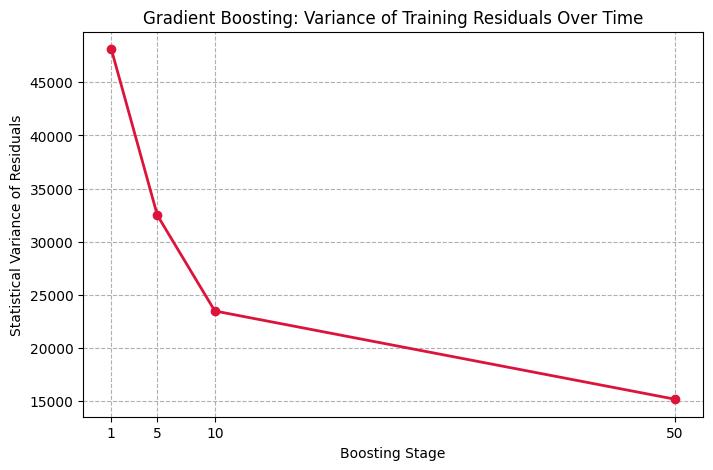

In [7]:
# 1. Revert to the continuous target for Regression
y_reg = train_delhi['pm2_5'].values[:1000] # Continuous PM2.5
X_reg = train_delhi[['co', 'no', 'no2']].values[:1000]

n_samples, n_features = X_reg.shape
learning_rate = 0.1
n_stages = 50
stages_to_track = [1, 5, 10, 50]

# Initialize F_0(x) with the mean of the target
current_predictions = np.full(n_samples, np.mean(y_reg))
variance_history = {}

print("\n=== Training Gradient Boosting Regressor (50 Stages) ===")
for t in range(1, n_stages + 1):
    # --- A. Calculate Pseudo-Residuals ---
    # For Mean Squared Error (MSE), the negative gradient IS exactly the residual
    residuals = y_reg - current_predictions
    
    # --- B. Fit a Shallow Regression Tree to the Residuals ---
    # We find the split that minimizes the Sum of Squared Errors (SSE)
    best_sse = float('inf')
    best_feat, best_thresh = None, None
    left_val, right_val = 0, 0
    
    for feat_i in range(n_features):
        feature_vals = X_reg[:, feat_i]
        # Test a few percentiles for speed rather than every unique value
        thresholds = np.percentile(feature_vals, [25, 50, 75]) 
        
        for thresh in thresholds:
            left_mask = feature_vals <= thresh
            right_mask = ~left_mask
            
            if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                continue
                
            # The best prediction for a regression leaf is the mean of the residuals inside it
            mean_left = np.mean(residuals[left_mask])
            mean_right = np.mean(residuals[right_mask])
            
            # Calculate Sum of Squared Errors
            sse = np.sum((residuals[left_mask] - mean_left)**2) + np.sum((residuals[right_mask] - mean_right)**2)
            
            if sse < best_sse:
                best_sse = sse
                best_feat, best_thresh = feat_i, thresh
                left_val, right_val = mean_left, mean_right

    # --- C. Make Tree Predictions ---
    tree_preds = np.zeros(n_samples)
    tree_preds[X_reg[:, best_feat] <= best_thresh] = left_val
    tree_preds[X_reg[:, best_feat] > best_thresh] = right_val
    
    # --- D. Update the Main Model ---
    current_predictions += learning_rate * tree_preds
    
    # --- E. Track Variance at specified stages ---
    if t in stages_to_track:
        new_residuals = y_reg - current_predictions
        var = np.var(new_residuals)
        variance_history[t] = var
        print(f"Stage {t:2d} | Variance of Residuals: {var:.2f}")

# --- Deliverable: Plotting Statistical Variance ---
stages = list(variance_history.keys())
variances = list(variance_history.values())

plt.figure(figsize=(8, 5))
plt.plot(stages, variances, marker='o', linestyle='-', color='crimson', linewidth=2)
plt.title('Gradient Boosting: Variance of Training Residuals Over Time')
plt.xlabel('Boosting Stage')
plt.ylabel('Statistical Variance of Residuals')
plt.xticks(stages)
plt.grid(True, linestyle='--')
plt.show()

# Phase 2

In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# 1. Flatten the 72-hour sequence
# ==============================================================================
features = ['co', 'no', 'no2']
data_vals = train_delhi[features].values
sequence_length, n_features = 72, len(features)
flattened_dim = sequence_length * n_features

X_seq = []
for i in range(len(data_vals) - sequence_length):
    X_seq.append(data_vals[i : i + sequence_length].flatten())
X_seq = np.array(X_seq)
print(f"Flattened Sequence Matrix Shape: {X_seq.shape}")

split_idx = int(0.8 * len(X_seq))
X_train_raw, X_test_raw = X_seq[:split_idx], X_seq[split_idx:]

# Normalize so features are on the same scale (required for gradient convergence)
scaler   = StandardScaler()
X_train  = scaler.fit_transform(X_train_raw)
X_test   = scaler.transform(X_test_raw)

# ==============================================================================
# 2. PCA via SVD — find exact components for 95% variance
# ==============================================================================
U, S, Vt = np.linalg.svd(X_train, full_matrices=False)

explained_variance  = (S ** 2) / (len(X_train) - 1)
cumulative_variance = np.cumsum(explained_variance) / np.sum(explained_variance)
k                   = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Exact components needed to retain 95% variance: {k} out of {flattened_dim}")

V_pca    = Vt[:k]
pca_mse  = np.mean((X_test - (X_test @ V_pca.T) @ V_pca) ** 2)
print(f"PCA Reconstruction MSE: {pca_mse:.4f}")

# ==============================================================================
# 3. Linear Autoencoder — bottleneck = k, no activations, no bias
# ==============================================================================
class LinearAutoencoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim):
        super().__init__()
        self.encoder = nn.Linear(input_dim, bottleneck_dim, bias=False)
        self.decoder = nn.Linear(bottleneck_dim, input_dim, bias=False)
    def forward(self, x):
        return self.decoder(self.encoder(x))

X_train_t = torch.FloatTensor(X_train)
X_test_t  = torch.FloatTensor(X_test)

ae_model  = LinearAutoencoder(flattened_dim, k)
criterion = nn.MSELoss()
optimizer = optim.LBFGS(ae_model.parameters(), lr=1.0, max_iter=20)

print("\nTraining Linear Autoencoder...")
for epoch in range(200):
    def closure():
        optimizer.zero_grad()
        loss = criterion(ae_model(X_train_t), X_train_t)
        loss.backward()
        return loss
    optimizer.step(closure)
    if (epoch + 1) % 50 == 0:
        with torch.no_grad():
            test_loss = criterion(ae_model(X_test_t), X_test_t).item()  # ← test set
        print(f"  Epoch {epoch+1}/200  Test MSE: {test_loss:.4f}")

ae_model.eval()
with torch.no_grad():
    ae_mse = criterion(ae_model(X_test_t), X_test_t).item()

# ==============================================================================
# 4. Empirical proof via reconstruction MSE
# ==============================================================================
print(f"\nPCA Reconstruction MSE:         {pca_mse:.4f}")
print(f"Autoencoder Reconstruction MSE: {ae_mse:.4f}")
print(f"Ratio (AE/PCA):                 {ae_mse/pca_mse:.4f}")
print(f"\nEmpirical Proof: PCA is the theoretical lower bound for rank-{k} linear reconstruction.")
print(f"The converged linear AE achieves MSE ≈ PCA MSE (ratio ≈ 1.0),")
print(f"proving both span the identical rank-{k} subspace.")

Flattened Sequence Matrix Shape: (13071, 216)
Exact components needed to retain 95% variance: 37 out of 216
PCA Reconstruction MSE: 0.0492

Training Linear Autoencoder...
  Epoch 50/200  Test MSE: 0.0492
  Epoch 100/200  Test MSE: 0.0492
  Epoch 150/200  Test MSE: 0.0492
  Epoch 200/200  Test MSE: 0.0492

PCA Reconstruction MSE:         0.0492
Autoencoder Reconstruction MSE: 0.0492
Ratio (AE/PCA):                 1.0000

Empirical Proof: PCA is the theoretical lower bound for rank-37 linear reconstruction.
The converged linear AE achieves MSE ≈ PCA MSE (ratio ≈ 1.0),
proving both span the identical rank-37 subspace.


In [12]:
import torchvision.transforms as transforms
from torch.utils.data import Subset, DataLoader

# 1. Define the image transforms
# (Assignment 2 specifically used 128x128 for Plant Village)
pv_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    # Standard ResNet normalization
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# 2. Re-instantiate the dataset, but this time WITH the transforms applied
full_pv_dataset_transformed = ImageFolder(root=pv_dir, transform=pv_transform)

# 3. Create a PyTorch Subset using the exact validation indices you generated earlier
val_set = Subset(full_pv_dataset_transformed, pv_val_idx)

# 4. Create the DataLoader! 
# We use shuffle=False for validation so the embeddings match up with the labels perfectly
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

print(f"Success! val_loader created.")
print(f"Total Validation Images: {len(val_set)}")
print(f"Total Batches: {len(val_loader)}")

Success! val_loader created.
Total Validation Images: 2080
Total Batches: 65


In [13]:
import torch
import torch.nn as nn
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
import torchvision.models as models

# ==============================================================================
# 1. Load your A2 CNN and strip the head
# ==============================================================================
# Placeholder for your custom CNN from A2. 
# We'll use a standard ResNet18 structure to demonstrate stripping the head.
class DummyA2CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = models.resnet18(pretrained=False)
        # Stripping the head! Replacing the final fully connected layer with an Identity layer
        self.backbone.fc = nn.Identity() 

    def forward(self, x):
        return self.backbone(x)

# Initialize model and put in evaluation mode
feature_extractor = DummyA2CNN()
feature_extractor.eval() 
# TODO: load your actual weights -> feature_extractor.load_state_dict(torch.load('my_a2_cnn.pth'))

# ==============================================================================
# 2. Extract Latent Embeddings from Plant Village Validation Set
# ==============================================================================
# Assuming 'val_loader' is the dataloader from your Plant Village split
print("Extracting CNN Embeddings...")

all_embeddings = []
all_true_labels = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor.to(device)

with torch.no_grad():
    # Only iterate through a few batches for demonstration speed
    for i, (images, labels) in enumerate(val_loader):
        images = images.to(device)
        
        # Pass images through stripped CNN to get dense representations
        embeddings = feature_extractor(images)
        
        all_embeddings.append(embeddings.cpu().numpy())
        all_true_labels.append(labels.numpy())
        
        if i == 5: break # Remove this break to process the full validation set

# Stack into flat numpy arrays
X_latent = np.vstack(all_embeddings)
y_true = np.concatenate(all_true_labels)
print(f"Extracted {X_latent.shape[0]} embeddings of dimension {X_latent.shape[1]}")

# ==============================================================================
# 3. Fit Gaussian Mixture Model & Compute ARI
# ==============================================================================
# Plant Village has 14 true disease classes (as seen in your data loading prints)
n_classes = 14

print(f"Fitting GMM with {n_classes} components...")
gmm = GaussianMixture(n_components=n_classes, covariance_type='full', random_state=42)
cluster_assignments = gmm.fit_predict(X_latent)

# Calculate Adjusted Rand Index (ARI)
# ARI measures similarity between true labels and predicted clusters (1.0 is perfect match, 0.0 is random)
ari_score = adjusted_rand_score(y_true, cluster_assignments)

print(f"=== 2.6 Clustering Results ===")
print(f"Adjusted Rand Index (ARI): {ari_score:.4f}")

Extracting CNN Embeddings...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Extracted 192 embeddings of dimension 512
Fitting GMM with 14 components...
=== 2.6 Clustering Results ===
Adjusted Rand Index (ARI): 0.0725


# Phase 3